In [3]:
import numpy as np
import matplotlib.pyplot as plt
import joblib
import pandas as pd
plt.style.use("fivethirtyeight") #This style makes plots look cleaner and more modern

In [45]:
class Perceptron:
  def __init__(self,eta,epochs):
    self.weights = np.random.randn(3) * 1e-4
    print(f"Weights:{self.weights}")
    self.eta = eta
    self.epochs = epochs


  def activation_function (self,input,weights):
    dot = np.dot(input,weights)  #x1.w1 + x2.w2+ ....
    return np.where(dot > 0, 1, 0) #categorized in 1 or 0


  def fit(self,X,y):
    self.X = X
    self.y = y

    x_with_bias = np.c_[self.X, -np.ones((len(self.X), 1))] ## concactination
    print(f"x_with_bias: {x_with_bias}")

    for i in range(self.epochs):
      print(f"Epochs {i}")
      y_pred = self.activation_function(x_with_bias,self.weights)
      print(f"y_preidictions: {y_pred}")

      error = self.y - y_pred
      print(f"Error: {error}")

      self.weights = self.weights + self.eta * np.dot(x_with_bias.T, error)
      print(f"Updated weights: {self.weights}")
      print("#############\n")

    #After training is finished,
    def predict(self,X):
      x_with_bias = np.c_(self.X, -np.ones(len(self.X),1))
      return self.activation_function (x_with_bias,self.weights)




##AND Operation:

In [8]:
data = {"x1" : [0,0,1,1], "x2" : [0,1,0,1], "y" : [0,0,0,1]}


In [10]:
AND = pd.DataFrame(data)
AND

,x1,x2,y
0,0,0,0
1,0,1,0
2,1,0,0
3,1,1,1


In [12]:
X = AND.drop('y', axis =1)

In [21]:
y = AND['y']  #There is only one column, so Pandas returns a Series.

y.to_frame()

,y
0,0
1,0
2,0
3,1


In [22]:
X

,x1,x2
0,0,0
1,0,1
2,1,0
3,1,1


In [23]:
y

,y
0,0
1,0
2,0
3,1


In [46]:
model = Perceptron(eta = 0.5, epochs =10)
model.fit(X,y)

Weights:[-1.67768226e-04 -8.00561484e-05  1.46594733e-05]
x_with_bias: [[ 0.  0. -1.]
 [ 0.  1. -1.]
 [ 1.  0. -1.]
 [ 1.  1. -1.]]
Epochs 0
y_preidictions: [0 0 0 0]
Error: 0    0
1    0
2    0
3    1
Name: y, dtype: int64
Updated weights: [ 0.49983223  0.49991994 -0.49998534]
#############

Epochs 1
y_preidictions: [1 1 1 1]
Error: 0   -1
1   -1
2   -1
3    0
Name: y, dtype: int64
Updated weights: [-1.67768226e-04 -8.00561484e-05  1.00001466e+00]
#############

Epochs 2
y_preidictions: [0 0 0 0]
Error: 0    0
1    0
2    0
3    1
Name: y, dtype: int64
Updated weights: [0.49983223 0.49991994 0.50001466]
#############

Epochs 3
y_preidictions: [0 0 0 1]
Error: 0    0
1    0
2    0
3    0
Name: y, dtype: int64
Updated weights: [0.49983223 0.49991994 0.50001466]
#############

Epochs 4
y_preidictions: [0 0 0 1]
Error: 0    0
1    0
2    0
3    0
Name: y, dtype: int64
Updated weights: [0.49983223 0.49991994 0.50001466]
#############

Epochs 5
y_preidictions: [0 0 0 1]
Error: 0    0
1    0

##OR Operation:

In [48]:
data = {"x1": [0,0,1,1], "x2": [0,1,0,1], "y": [0,1,1,1]}
OR = pd.DataFrame(data)

X = OR.drop("y", axis=1)
y = OR['y']
y.to_frame()



,y
0,0
1,1
2,1
3,1


In [49]:
model = Perceptron(eta = 0.5, epochs=10)
model.fit(X,y)

Weights:[-4.26508306e-06 -6.68625930e-06 -7.11558095e-05]
x_with_bias: [[ 0.  0. -1.]
 [ 0.  1. -1.]
 [ 1.  0. -1.]
 [ 1.  1. -1.]]
Epochs 0
y_preidictions: [1 1 1 1]
Error: 0   -1
1    0
2    0
3    0
Name: y, dtype: int64
Updated weights: [-4.26508306e-06 -6.68625930e-06  4.99928844e-01]
#############

Epochs 1
y_preidictions: [0 0 0 0]
Error: 0    0
1    1
2    1
3    1
Name: y, dtype: int64
Updated weights: [ 0.99999573  0.99999331 -1.00007116]
#############

Epochs 2
y_preidictions: [1 1 1 1]
Error: 0   -1
1    0
2    0
3    0
Name: y, dtype: int64
Updated weights: [ 0.99999573  0.99999331 -0.50007116]
#############

Epochs 3
y_preidictions: [1 1 1 1]
Error: 0   -1
1    0
2    0
3    0
Name: y, dtype: int64
Updated weights: [ 9.99995735e-01  9.99993314e-01 -7.11558095e-05]
#############

Epochs 4
y_preidictions: [1 1 1 1]
Error: 0   -1
1    0
2    0
3    0
Name: y, dtype: int64
Updated weights: [0.99999573 0.99999331 0.49992884]
#############

Epochs 5
y_preidictions: [0 1 1 1]
Er

##XOR Operation:

In [50]:
data = {"x1": [0,0,1,1], "x2": [0,1,0,1], "y": [0,1,1,0]}
XOR = pd.DataFrame(data)

y = XOR['y']
y.to_frame()



,y
0,0
1,1
2,1
3,0


In [51]:
model = Perceptron(eta = 0.5, epochs=50)
model.fit(X,y)

Weights:[ 1.02807352e-04 -7.42510258e-05 -9.39003689e-05]
x_with_bias: [[ 0.  0. -1.]
 [ 0.  1. -1.]
 [ 1.  0. -1.]
 [ 1.  1. -1.]]
Epochs 0
y_preidictions: [1 1 1 1]
Error: 0   -1
1    0
2    0
3   -1
Name: y, dtype: int64
Updated weights: [-0.49989719 -0.50007425  0.9999061 ]
#############

Epochs 1
y_preidictions: [0 0 0 0]
Error: 0    0
1    1
2    1
3    0
Name: y, dtype: int64
Updated weights: [ 1.02807352e-04 -7.42510258e-05 -9.39003689e-05]
#############

Epochs 2
y_preidictions: [1 1 1 1]
Error: 0   -1
1    0
2    0
3   -1
Name: y, dtype: int64
Updated weights: [-0.49989719 -0.50007425  0.9999061 ]
#############

Epochs 3
y_preidictions: [0 0 0 0]
Error: 0    0
1    1
2    1
3    0
Name: y, dtype: int64
Updated weights: [ 1.02807352e-04 -7.42510258e-05 -9.39003689e-05]
#############

Epochs 4
y_preidictions: [1 1 1 1]
Error: 0   -1
1    0
2    0
3   -1
Name: y, dtype: int64
Updated weights: [-0.49989719 -0.50007425  0.9999061 ]
#############

Epochs 5
y_preidictions: [0 0 0 0]

##N.B: We can't implement the XOR gate in this way , bacause it's not a linearly separeable.

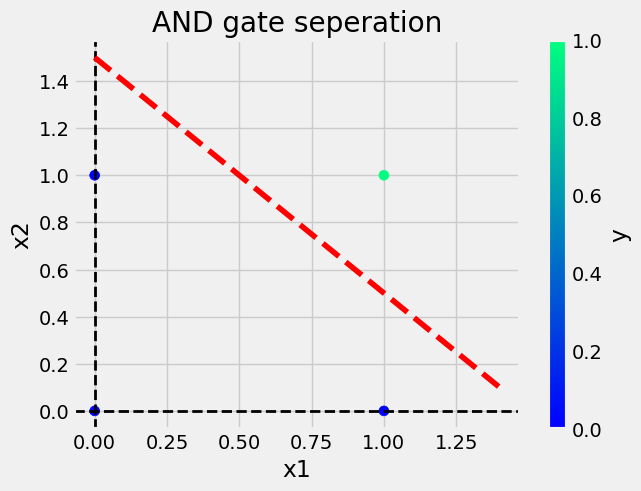

In [56]:
AND.plot(kind="scatter", x="x1", y="x2", c="y", s=50, cmap="winter")
plt.axhline(y=0, color="black", linestyle="--", linewidth=2)
plt.axvline(x=0, color="black", linestyle="--", linewidth=2)
plt.title("AND gate seperation")
x = np.linspace(0, 1.4) # >>> 50
y = 1.5 - 1*np.linspace(0, 1.4) # >>> 50

plt.plot(x, y, "r--")
plt.show()

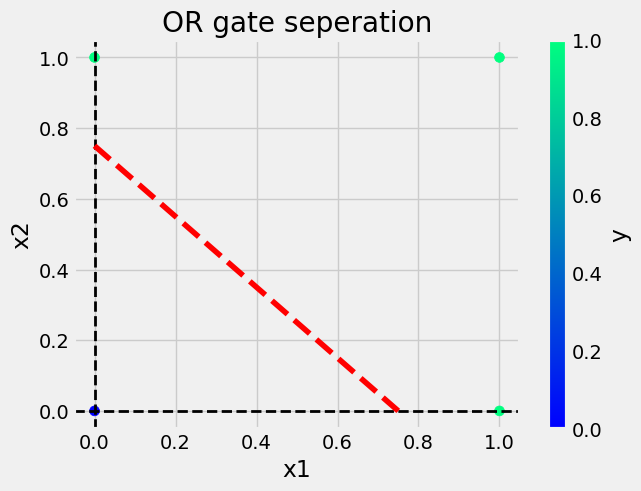

In [57]:
OR.plot(kind="scatter", x="x1", y="x2", c="y", s=50, cmap="winter")
plt.axhline(y = 0, color ="black", linestyle ="--", linewidth=2)
plt.axvline(x = 0, color ="black", linestyle ="--", linewidth=2)
plt.title("OR gate seperation")
plt.plot(np.linspace(0,0.75), 0.75 - 1*np.linspace(0,0.75), 'r--');
plt.show()

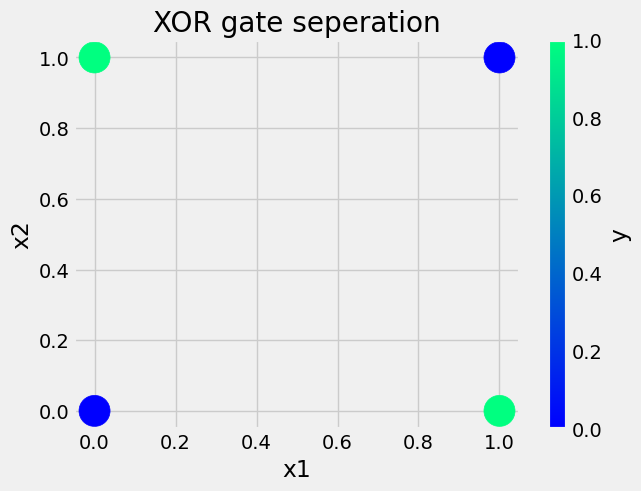

In [58]:
XOR.plot(kind="scatter", x="x1", y="x2", c="y", s=500, cmap="winter")
plt.title("XOR gate seperation")
plt.show()